### DECISION TREE CLASSIFIER MODELING

The cleaned dataset from exploratory data analysis is loaded.

The features and target variable are defined and split into train and test sets.

Features are scaled and encoded as required during preprocessing.

The parameter **class_weight** is used to address the class imbalance.

A pipeline is used and model parameters are optimized using **HalvingRandomSearchCV**.     

**Classification report** and **confusion matrix** are used to verify the accuracy, precision, and recall as well as display the **true negatives**, **false positives**, **false negatives**, and **true positives**.   

**Costs** and **savings** are defined to support the **profit_loss_analysis**.   

The **thresholds** are tuned to optimize the profits.  
    
**Feature importance** is ranked and further analyzed using **SHAP**.    

The model **performance metrics**, **feature importances**, and **SHAP** importances are output and compared with other models in a models summary notebook.

The best model is chosen based on business goals that consider the relative cost of missing a churner (_false negatives_ - predicted not to churn but churned, loss of lifetime value), cost of false alarms (_false positives_ - predicted to churn but stayed, cost of retention offer) and _true positives_ (predicted to stay and actually stayed, saved lifetime value less the cost of retention offer).

In customer churn, missing churners (_recall_) is more expensive than false alarms (_precision_).  Recall is, therefore, optimized at the expense of precision and accuracy.     


**Import the required libraries**

In [1]:
import pandas as pd
import numpy as np
np.random.seed(42)
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import shap
import seaborn as sns
import math
import warnings
warnings.filterwarnings('ignore')

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import recall_score, precision_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, f1_score, accuracy_score
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

In [2]:
# Load the dataset
df = pd.read_csv('cleaned_data_ccp.csv')

In [3]:
# Define X and y
X = df.drop(['churn'], axis=1)
y = df['churn']

In [4]:
# Split to train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [5]:
# Define numeric features
numerical_columns = df.select_dtypes(include=['number']).columns.tolist()
numerical_columns

['age',
 'tenure_months',
 'monthly_logins',
 'weekly_active_days',
 'avg_session_time',
 'usage_growth_rate',
 'last_login_days_ago',
 'monthly_fee',
 'total_revenue',
 'payment_failures',
 'support_tickets',
 'avg_resolution_time',
 'csat_score',
 'escalations',
 'email_open_rate',
 'marketing_click_rate',
 'nps_score',
 'referral_count',
 'churn',
 'tenure_fee_interaction',
 'avg_monthly_usage',
 'charge_increase',
 'is_new_customer',
 'is_loyal_customer',
 'activity_ratio',
 'usage_trend',
 'auto_payment',
 'negative_customer',
 'no_referrals',
 'has_referrals',
 'high_referral_customer',
 'high_escalations',
 'referral_tenure',
 'loyal_monthly_customer',
 'tickets_support',
 'is_happy_customer',
 'not_happy_customer',
 'high_fee_customer',
 'budget_customer',
 'high_risk_flags1',
 'high_risk_flags2',
 'high_risk_flags5',
 'high_risk_flags6',
 'high_risk_flags7',
 'high_risk_flags8',
 'high_risk_flags9',
 'high_risk_flags10',
 'high_risk_flags11',
 'high_risk_flags12',
 'high_risk_

In [6]:
# Define numeric_cols less the target variable 'churn'
numeric_cols = [col for col in numerical_columns if col != 'churn']

print(f'There are {len(numeric_cols)} numeric columns.')

There are 117 numeric columns.


In [7]:
# Verify categorical features for encoding
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols

['gender',
 'country',
 'city',
 'customer_segment',
 'signup_channel',
 'contract_type',
 'features_used',
 'payment_method',
 'discount_applied',
 'price_increase_last_3m',
 'complaint_type',
 'survey_response',
 'tenure_group']

In [8]:
# Define the ordinal and nominal features
ordinal_cols = ['contract_type','survey_response','customer_segment']
nominal_cols = [col for col in categorical_cols if col not in ordinal_cols]

print(f'There are {len(ordinal_cols)} ordinal columns and {len(nominal_cols)} nominal columns.')

There are 3 ordinal columns and 10 nominal columns.


In [9]:
# Verify 'contract_type', 'survey_response', and 'customer_segment'

print(df['contract_type'].value_counts(), '\n')
print(df['survey_response'].value_counts(), '\n')
print(df['customer_segment'].value_counts())

contract_type
Monthly      4967
Quarterly    3050
Yearly       1983
Name: count, dtype: int64 

survey_response
Satisfied      4975
Neutral        2978
Unsatisfied    2047
Name: count, dtype: int64 

customer_segment
Individual    5984
SME           3029
Enterprise     987
Name: count, dtype: int64


In [10]:
# Define ordinal categories
ordinal_categories=[
  ['Monthly','Quarterly','Yearly'],          # contract_type
  ['Unsatisfied','Neutral','Satisfied'],     # survey_response
  ['Individual','SME','Enterprise']          # customer_segment
]

In [11]:
# Define the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("ord", OrdinalEncoder(categories=ordinal_categories), ordinal_cols),
        ("nom", OneHotEncoder(drop=None, handle_unknown="ignore"), nominal_cols),
    ],
    remainder='passthrough'
)

In [12]:
# Build pipeline
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('dtree', DecisionTreeClassifier(class_weight='balanced', random_state=42))
])
pipe.fit(X_train, y_train)
pipe

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ord',
                                                  OrdinalEncoder(categories=[['Monthly',
                                                                              'Quarterly',
                                                                              'Yearly'],
                                                                             ['Unsatisfied',
                                                                              'Neutral',
                                                                              'Satisfied'],
                                                                             ['Individual',
                                                                              'SME',
                                                                              'Enterprise']]),
                                                  ['contract_type',
                                                   'survey_response',
                                                   'customer_segment']),
                                                 ('nom',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'country', 'city',
                                                   'signup_channel',
                                                   'features_used',
                                                   'payment_method',
                                                   'discount_applied',
                                                   'price_increase_last_3m',
                                                   'complaint_type',
                                                   'tenure_group'])])),
                ('dtree',
                 DecisionTreeClassifier(class_weight='balanced',
                                        random_state=42))])

In [13]:
# Accuracy of model on train and test data
pipe_acc_train = pipe.score(X_train, y_train)
pipe_acc_test = pipe.score(X_test, y_test)

print(f'The train accuracy of the model is {pipe_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {pipe_acc_test*100:.2f}%')

The train accuracy of the model is 100.00%
The test accuracy of the model is 84.55%


The overfit is addressed by tuning the model parameters.

In [14]:
# Build pipeline
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('dtree', DecisionTreeClassifier(class_weight='balanced', random_state=42))
])
pipe.fit(X_train, y_train)
pipe

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ord',
                                                  OrdinalEncoder(categories=[['Monthly',
                                                                              'Quarterly',
                                                                              'Yearly'],
                                                                             ['Unsatisfied',
                                                                              'Neutral',
                                                                              'Satisfied'],
                                                                             ['Individual',
                                                                              'SME',
                                                                              'Enterprise']]),
                                                  ['contract_type',
                                                   'survey_response',
                                                   'customer_segment']),
                                                 ('nom',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'country', 'city',
                                                   'signup_channel',
                                                   'features_used',
                                                   'payment_method',
                                                   'discount_applied',
                                                   'price_increase_last_3m',
                                                   'complaint_type',
                                                   'tenure_group'])])),
                ('dtree',
                 DecisionTreeClassifier(class_weight='balanced',
                                        random_state=42))])

In [15]:
# Define the hyperparameter grid
param_grid = {
    'dtree__criterion': ['gini', 'entropy'],
    'dtree__max_depth': [5, 6, 7, None],
    'dtree__min_samples_split': [2, 5, 10],
    'dtree__ccp_alpha': [0.0, 0.001, 0.002, 0.005, 0.01],
    'dtree__min_samples_leaf': [2, 5, 10]
}

In [16]:
# Run HalvingRandomSearchCV to find the optimum mix of parameters
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid = HalvingRandomSearchCV(pipe, param_grid, cv=cv, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

print(f'Best parameters: {grid.best_params_}')
print(f'Best score: {grid.best_score_:.4f}')

Best parameters: {'dtree__min_samples_split': 5, 'dtree__min_samples_leaf': 2, 'dtree__max_depth': 5, 'dtree__criterion': 'gini', 'dtree__ccp_alpha': 0.01}
Best score: 0.3684


In [17]:
# Access the optimized xgb_pipe1 pipeline model
best_model = grid.best_estimator_
best_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ord',
                                                  OrdinalEncoder(categories=[['Monthly',
                                                                              'Quarterly',
                                                                              'Yearly'],
                                                                             ['Unsatisfied',
                                                                              'Neutral',
                                                                              'Satisfied'],
                                                                             ['Individual',
                                                                              'SME',
                                                                              'Enterprise']]),
                                                  ['contract_type',
                                                   'survey_response',
                                                   'customer_segment']),
                                                 ('nom',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'country', 'city',
                                                   'signup_channel',
                                                   'features_used',
                                                   'payment_method',
                                                   'discount_applied',
                                                   'price_increase_last_3m',
                                                   'complaint_type',
                                                   'tenure_group'])])),
                ('dtree',
                 DecisionTreeClassifier(ccp_alpha=0.01, class_weight='balanced',
                                        max_depth=5, min_samples_leaf=2,
                                        min_samples_split=5,
                                        random_state=42))])

In [18]:
# Accuracy of model on train and test data
best_model_acc_train = best_model.score(X_train, y_train)
best_model_acc_test = best_model.score(X_test, y_test)

print(f'The train accuracy of the model is {best_model_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {best_model_acc_test*100:.2f}%')

The train accuracy of the model is 72.50%
The test accuracy of the model is 71.25%


In [19]:
# Generate classification report
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.70      0.81      1796
           1       0.24      0.85      0.38       204

    accuracy                           0.71      2000
   macro avg       0.61      0.77      0.59      2000
weighted avg       0.90      0.71      0.77      2000



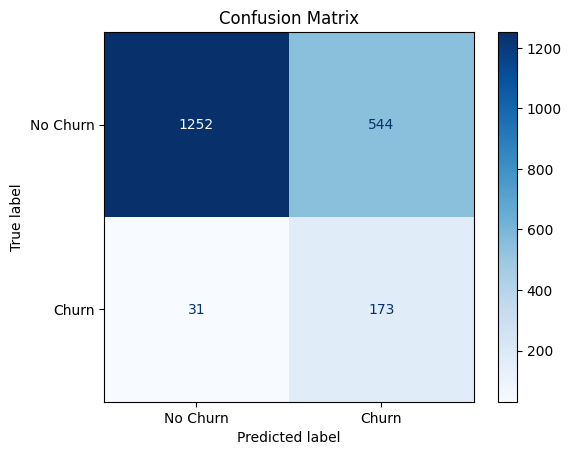

In [20]:
# Display confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn','Churn'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [21]:
# Values for true negative (tn), false positive (fp), false negative (fn), and true positive (tp)
tn, fp, fn, tp = cm.ravel()

print(f' fp: {fp} \n fn: {fn} \n tp: {tp} \n tn: {tn}')

 fp: 544 
 fn: 31 
 tp: 173 
 tn: 1252


In [22]:
# Calculations for accuracy, precision, recall
accuracy = round((tp + tn)/len(y_test), 4)
precision = round(tp/(tp + fp), 4)
recall = round(tp/(tp + fn), 4)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'-'*15)

Accuracy: 0.71
Precision: 0.24
Recall: 0.85
---------------


In [23]:
# Calculate f2 score
beta = 2
f2_score = (1 + beta**2) * (precision * recall) / (beta**2 * precision + recall)

print(f'The f2 score is {f2_score:.4f}')

The f2 score is 0.5643


**Profit/Loss analysis**     
The profit/loss analysis compares the relative performance of the models financially. For demonstration purposes, the following values are used:     
**L** = value of retaining a churner (lifetime value) is \$500      
**C** = cost of retention action is \$40     
True positives (**TP**) are correctly identified churners (retention action is spent but the value is saved).   
False positives (**FP**) stay but predicted to leave (retention action is spent but no value is saved).    
False negatives (**FN)** are predicted not to leave but leave (no retention action spent but value is lost).    
True negatives (**TN**) are correctly predicted not to leave (no retention action spent and no value is lost).

In [24]:
# Profit/loss analysis
L=500
C=40
profit_loss = tp*(L - C) - fp*C - fn*L

print(f'The profit or loss is ${profit_loss:,}')

The profit or loss is $42,320


**ROC Curve**    
The ROC Curve is plotted and the optimum threshold is obtained.

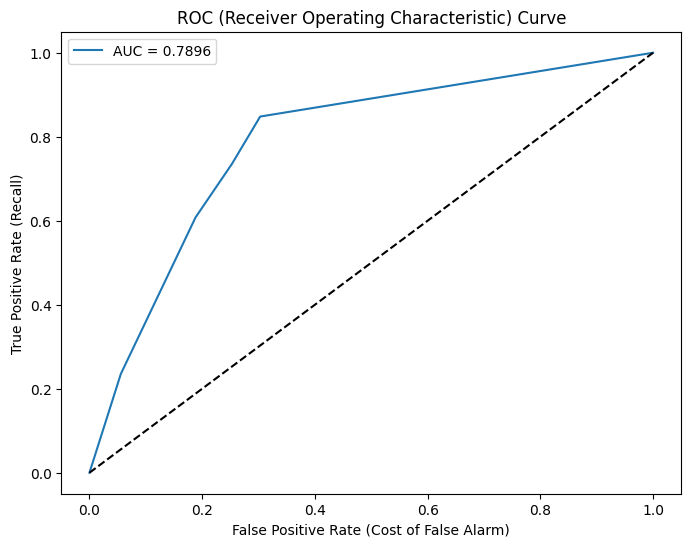

In [25]:
# Plot the ROC Curve
y_probs = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = round(roc_auc_score(y_test, y_probs), 4)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_probs):.4f}')
plt.plot([0,1], [0,1], 'k--') # diagonal line representing random guessing
plt.title('ROC (Receiver Operating Characteristic) Curve')
plt.xlabel('False Positive Rate (Cost of False Alarm)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

In [26]:
# Find the optimal threshold from the ROC Curve that maximizes Youden's J
optimal_idx = np.argmax(tpr-fpr)
optimal_threshold = thresholds[optimal_idx]

print(f'The optimal threshold is {optimal_threshold :.4f}')

The optimal threshold is 0.6979


**Threshold that maximizes profit**    
The threshold that maximizes profit is obtained from the precision-recall curve

In [27]:
# Calculate precision and recall for all thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
avg_precision = average_precision_score(y_test, y_probs)

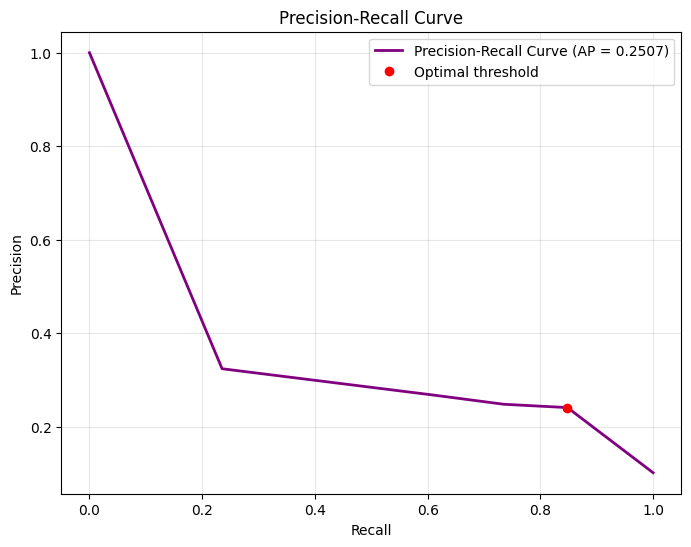

In [28]:
# Plot the precision-recall curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {avg_precision:.4f})', color='purple', lw=2)
# Mark the optimal threshold on the plot
idx = np.argmin(np.abs(thresholds-optimal_threshold))
plt.plot(recall[idx], precision[idx], 'ro', label='Optimal threshold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.show()

In [29]:
# Evaluate precision and recall at different thresholds
thresholds = np.arange(0, 0.25, 0.01)
for threshold in thresholds:
    preds = (y_probs >= threshold).astype(int)
    print(f'Threshold={threshold:.2f} | Precision={precision_score(y_test, preds):.2f} | Recall={recall_score(y_test, preds):.2f}')

Threshold=0.00 | Precision=0.10 | Recall=1.00
Threshold=0.01 | Precision=0.10 | Recall=1.00
Threshold=0.02 | Precision=0.10 | Recall=1.00
Threshold=0.03 | Precision=0.10 | Recall=1.00
Threshold=0.04 | Precision=0.10 | Recall=1.00
Threshold=0.05 | Precision=0.10 | Recall=1.00
Threshold=0.06 | Precision=0.10 | Recall=1.00
Threshold=0.07 | Precision=0.10 | Recall=1.00
Threshold=0.08 | Precision=0.10 | Recall=1.00
Threshold=0.09 | Precision=0.10 | Recall=1.00
Threshold=0.10 | Precision=0.10 | Recall=1.00
Threshold=0.11 | Precision=0.10 | Recall=1.00
Threshold=0.12 | Precision=0.10 | Recall=1.00
Threshold=0.13 | Precision=0.10 | Recall=1.00
Threshold=0.14 | Precision=0.10 | Recall=1.00
Threshold=0.15 | Precision=0.10 | Recall=1.00
Threshold=0.16 | Precision=0.10 | Recall=1.00
Threshold=0.17 | Precision=0.10 | Recall=1.00
Threshold=0.18 | Precision=0.24 | Recall=0.85
Threshold=0.19 | Precision=0.24 | Recall=0.85
Threshold=0.20 | Precision=0.24 | Recall=0.85
Threshold=0.21 | Precision=0.24 | 

In [30]:
# Determine the threshold that maximizes profit
profits = []
for t in thresholds:
    y_pred = (y_probs >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    profit_loss = tp*(L - C) - fp*C - fn*L
    profits.append(profit_loss)

best_threshold = thresholds[np.argmax(profits)]

print(f'The threshold that maximizes profit is {best_threshold}')

The threshold that maximizes profit is 0.18


In [31]:
# Use the threshold that maximizes profit
y_pred = (y_probs >= best_threshold).astype(int)

In [32]:
# Generate classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.70      0.81      1796
           1       0.24      0.85      0.38       204

    accuracy                           0.71      2000
   macro avg       0.61      0.77      0.59      2000
weighted avg       0.90      0.71      0.77      2000



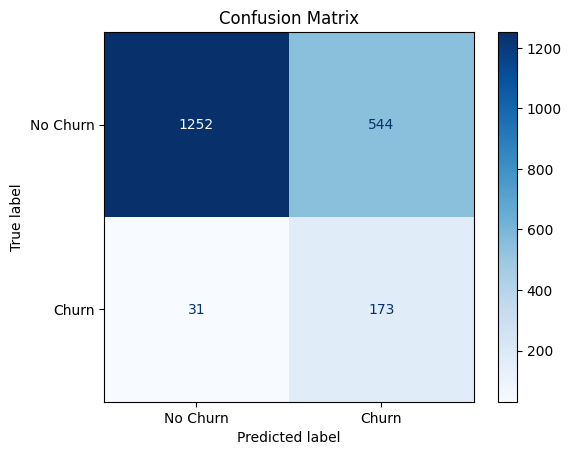

In [33]:
# Display confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn','Churn'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [34]:
# Values for true negative (tn), false positive (fp), false negative (fn), and true positive (tp)
tn, fp, fn, tp = cm.ravel()

print(f' fp: {fp} \n fn: {fn} \n tp: {tp} \n tn: {tn}')

 fp: 544 
 fn: 31 
 tp: 173 
 tn: 1252


In [35]:
# Calculations for accuracy, precision, recall
accuracy = round((tp + tn)/len(y_test), 4)
precision = round(tp/(tp + fp), 4)
recall = round(tp/(tp + fn), 4)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'-'*15)

Accuracy: 0.71
Precision: 0.24
Recall: 0.85
---------------


In [36]:
# Calculate f2 score
beta = 2
f2_score = round((1 + beta**2) * (precision * recall) / (beta**2 * precision + recall), 4)

print(f'The f2 score is {f2_score:.4f}')

The f2 score is 0.5643


In [37]:
# Profit/loss analysis
profit_loss = tp*(L - C) - fp*C - fn*L

print(f'The profit or loss is ${profit_loss:,}')

The profit or loss is $42,320


**Feature Selection**

In [38]:
# Verify number of features
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

print(f'The number of transformed features is {len(feature_names)}')

The number of transformed features is 157


In [39]:
# Determine the best number of features
results = []
feature_counts = [100, 120, 140, 157]
# Transform
X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

for k in feature_counts:
    selector = SelectFromModel(
        RandomForestClassifier(
            class_weight='balanced',
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ),
        threshold=-float("inf"),
        max_features=k
    )
    # Feature selection
    X_train_selected = selector.fit_transform(
        X_train_trans,
        y_train
    )
    X_test_selected = selector.transform(
        X_test_trans
    )
    # Final model
    model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
    model.fit(X_train_selected, y_train)
    # Predictions
    y_pred = model.predict(X_test_selected)
    y_proba = model.predict_proba(X_test_selected)[:, 1]
    # Metrics
    recall = recall_score(
        y_test,
        y_pred,
        average='macro'
    )
    f1 = f1_score(
        y_test,
        y_pred,
        average='macro'
    )
    accuracy = accuracy_score(
        y_test,
        y_pred
    )
    auc = roc_auc_score(y_test, y_proba)
    # Store results
    results.append({
        "num_features": k,
        "accuracy": accuracy,
        "recall": recall,
        "f1": f1,
        "auc": auc
    })
    # Selected features
    feature_names = preprocessor.get_feature_names_out()
    selected_features = feature_names[
      selector.get_support()
    ]

    print(f"\nTop {k} Features:")
    print(selected_features.tolist())

# Summary table
results_df = pd.DataFrame(results)

print("\nPerformance Summary:")
print(results_df)


Top 100 Features:
['ord__contract_type', 'ord__survey_response', 'ord__customer_segment', 'nom__gender_Female', 'nom__gender_Male', 'nom__country_Australia', 'nom__country_Bangladesh', 'nom__country_Canada', 'nom__country_Germany', 'nom__country_India', 'nom__country_UK', 'nom__country_USA', 'nom__city_Berlin', 'nom__city_Delhi', 'nom__city_Dhaka', 'nom__city_London', 'nom__city_New York', 'nom__city_Sydney', 'nom__city_Toronto', 'nom__signup_channel_Mobile', 'nom__signup_channel_Referral', 'nom__signup_channel_Web', 'nom__features_used_Few', 'nom__features_used_Medium', 'nom__payment_method_Bank Transfer', 'nom__payment_method_Card', 'nom__payment_method_PayPal', 'nom__discount_applied_No', 'nom__discount_applied_Yes', 'nom__price_increase_last_3m_No', 'nom__price_increase_last_3m_Yes', 'nom__complaint_type_Billing', 'nom__complaint_type_Service', 'nom__complaint_type_Technical', 'nom__tenure_group_(0, 4]', 'nom__tenure_group_(24, 36]', 'nom__tenure_group_(36, 52]', 'nom__tenure_grou

Choose 120 features (the performance difference is slight compared to the significant noise reduction).

In [40]:
# Define final selector
selector = SelectFromModel(
    RandomForestClassifier(
        class_weight='balanced',
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    threshold=-float("inf"),
    max_features=120
)

In [41]:
# Build pipeline
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ("selector", selector),
    ('dtree', DecisionTreeClassifier(class_weight='balanced', random_state=42))
])
pipe.fit(X_train, y_train)
pipe

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ord',
                                                  OrdinalEncoder(categories=[['Monthly',
                                                                              'Quarterly',
                                                                              'Yearly'],
                                                                             ['Unsatisfied',
                                                                              'Neutral',
                                                                              'Satisfied'],
                                                                             ['Individual',
                                                                              'SME',
                                                                              'Enterprise']]),
                                                  ['contract_type',
                                                   'survey_response',
                                                   'customer_segment']),
                                                 ('nom',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'country'...
                                                   'features_used',
                                                   'payment_method',
                                                   'discount_applied',
                                                   'price_increase_last_3m',
                                                   'complaint_type',
                                                   'tenure_group'])])),
                ('selector',
                 SelectFromModel(estimator=RandomForestClassifier(class_weight='balanced',
                                                                  n_estimators=300,
                                                                  n_jobs=-1,
                                                                  random_state=42),
                                 max_features=120, threshold=-inf)),
                ('dtree',
                 DecisionTreeClassifier(class_weight='balanced',
                                        random_state=42))])

In [42]:
# Define the hyperparameter grid
param_grid = {
    'dtree__criterion': ['gini', 'entropy'],
    'dtree__max_depth': [5, 6, 7, None],
    'dtree__min_samples_split': [2, 5, 10],
    'dtree__ccp_alpha': [0.0, 0.001, 0.002, 0.005, 0.01],
    'dtree__min_samples_leaf': [2, 5, 10]
}

In [43]:
# Run HalvingRandomSearchCV to find the optimum mix of parameters
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid = HalvingRandomSearchCV(pipe, param_grid, cv=cv, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

print(f'Best parameters: {grid.best_params_}')
print(f'Best score: {grid.best_score_:.4f}')

Best parameters: {'dtree__min_samples_split': 10, 'dtree__min_samples_leaf': 10, 'dtree__max_depth': 5, 'dtree__criterion': 'entropy', 'dtree__ccp_alpha': 0.01}
Best score: 0.3557


In [44]:
# Access the optimized xgb_pipe1 pipeline model
best_model = grid.best_estimator_
best_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ord',
                                                  OrdinalEncoder(categories=[['Monthly',
                                                                              'Quarterly',
                                                                              'Yearly'],
                                                                             ['Unsatisfied',
                                                                              'Neutral',
                                                                              'Satisfied'],
                                                                             ['Individual',
                                                                              'SME',
                                                                              'Enterprise']]),
                                                  ['contract_type',
                                                   'survey_response',
                                                   'customer_segment']),
                                                 ('nom',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'country'...
                                                   'complaint_type',
                                                   'tenure_group'])])),
                ('selector',
                 SelectFromModel(estimator=RandomForestClassifier(class_weight='balanced',
                                                                  n_estimators=300,
                                                                  n_jobs=-1,
                                                                  random_state=42),
                                 max_features=120, threshold=-inf)),
                ('dtree',
                 DecisionTreeClassifier(ccp_alpha=0.01, class_weight='balanced',
                                        criterion='entropy', max_depth=5,
                                        min_samples_leaf=10,
                                        min_samples_split=10,
                                        random_state=42))])

In [45]:
# Accuracy of model on train and test data
best_model_acc_train = best_model.score(X_train, y_train)
best_model_acc_test = best_model.score(X_test, y_test)

print(f'The train accuracy of the model is {best_model_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {best_model_acc_test*100:.2f}%')

The train accuracy of the model is 70.49%
The test accuracy of the model is 69.40%


In [46]:
# Generate classification report
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.67      0.80      1796
           1       0.23      0.88      0.37       204

    accuracy                           0.69      2000
   macro avg       0.61      0.78      0.58      2000
weighted avg       0.90      0.69      0.75      2000



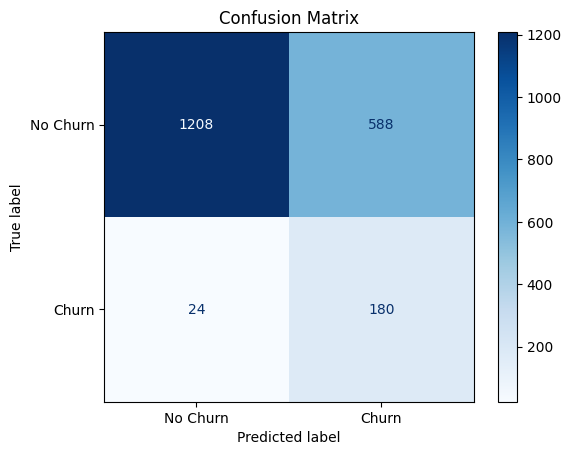

In [47]:
# Display confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn','Churn'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [48]:
# Values for true negative (tn), false positive (fp), false negative (fn), and true positive (tp)
tn, fp, fn, tp = cm.ravel()

print(f' fp: {fp} \n fn: {fn} \n tp: {tp} \n tn: {tn}')

 fp: 588 
 fn: 24 
 tp: 180 
 tn: 1208


In [49]:
# Calculations for accuracy, precision, recall
accuracy = round((tp + tn)/len(y_test), 4)
precision = round(tp/(tp + fp), 4)
recall = round(tp/(tp + fn), 4)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'-'*15)

Accuracy: 0.69
Precision: 0.23
Recall: 0.88
---------------


In [50]:
# Calculate f2 score
beta = 2
f2_score = round((1 + beta**2) * (precision * recall) / (beta**2 * precision + recall), 4)

print(f'The f2 score is {f2_score:.4f}')

The f2 score is 0.5682


In [51]:
# Profit/loss analysis
profit_loss = tp*(L - C) - fp*C - fn*L

print(f'The profit or loss is ${profit_loss:,}')

The profit or loss is $47,280


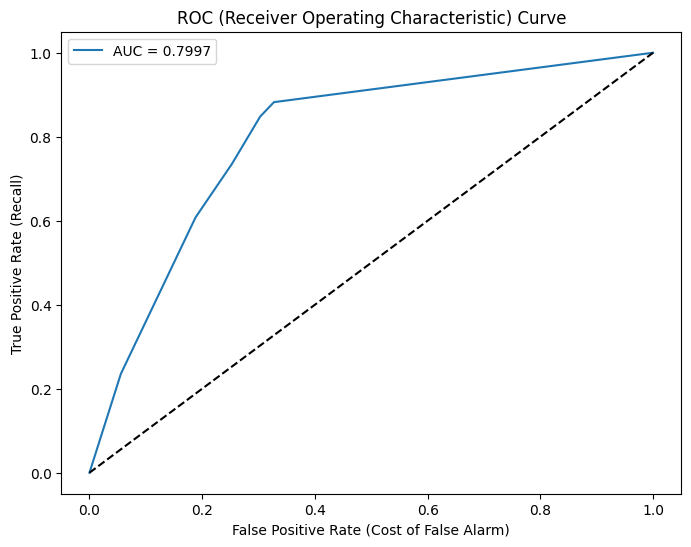

In [52]:
# Plot the ROC Curve
y_probs = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = round(roc_auc_score(y_test, y_probs), 4)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_probs):.4f}')
plt.plot([0,1], [0,1], 'k--') # diagonal line representing random guessing
plt.title('ROC (Receiver Operating Characteristic) Curve')
plt.xlabel('False Positive Rate (Cost of False Alarm)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

In [53]:
# Find the optimal threshold from the ROC Curve that maximizes Youden's J
optimal_idx = np.argmax(tpr-fpr)
optimal_threshold = thresholds[optimal_idx]

print(f'The optimal threshold is {optimal_threshold :.4f}')

The optimal threshold is 0.5580


In [54]:
# Calculate precision and recall for all thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
avg_precision = average_precision_score(y_test, y_probs)

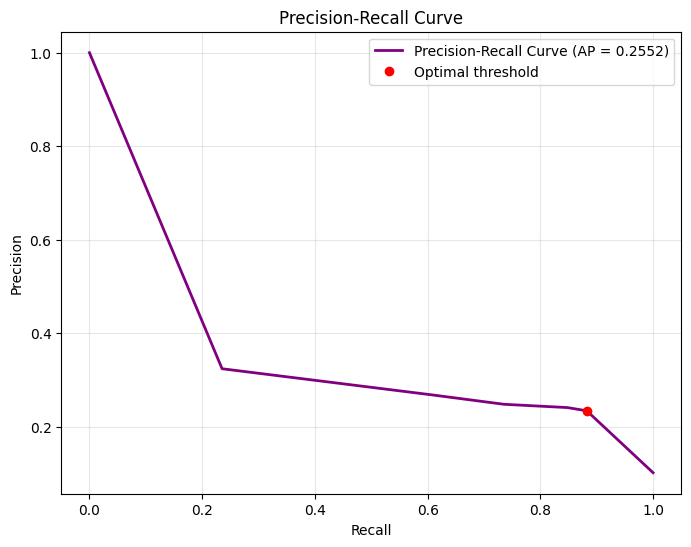

In [55]:
# Plot the precision-recall curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {avg_precision:.4f})', color='purple', lw=2)
# Mark the optimal threshold on the plot
idx = np.argmin(np.abs(thresholds-optimal_threshold))
plt.plot(recall[idx], precision[idx], 'ro', label='Optimal threshold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.show()

In [56]:
# Evaluate precision and recall at different thresholds
thresholds = np.arange(0, 0.25, 0.01)
for threshold in thresholds:
    preds = (y_probs >= threshold).astype(int)
    print(f'Threshold={threshold:.2f} | Precision={precision_score(y_test, preds):.2f} | Recall={recall_score(y_test, preds):.2f}')

Threshold=0.00 | Precision=0.10 | Recall=1.00
Threshold=0.01 | Precision=0.10 | Recall=1.00
Threshold=0.02 | Precision=0.10 | Recall=1.00
Threshold=0.03 | Precision=0.10 | Recall=1.00
Threshold=0.04 | Precision=0.10 | Recall=1.00
Threshold=0.05 | Precision=0.10 | Recall=1.00
Threshold=0.06 | Precision=0.10 | Recall=1.00
Threshold=0.07 | Precision=0.10 | Recall=1.00
Threshold=0.08 | Precision=0.10 | Recall=1.00
Threshold=0.09 | Precision=0.10 | Recall=1.00
Threshold=0.10 | Precision=0.10 | Recall=1.00
Threshold=0.11 | Precision=0.10 | Recall=1.00
Threshold=0.12 | Precision=0.10 | Recall=1.00
Threshold=0.13 | Precision=0.10 | Recall=1.00
Threshold=0.14 | Precision=0.10 | Recall=1.00
Threshold=0.15 | Precision=0.23 | Recall=0.88
Threshold=0.16 | Precision=0.23 | Recall=0.88
Threshold=0.17 | Precision=0.23 | Recall=0.88
Threshold=0.18 | Precision=0.23 | Recall=0.88
Threshold=0.19 | Precision=0.23 | Recall=0.88
Threshold=0.20 | Precision=0.23 | Recall=0.88
Threshold=0.21 | Precision=0.23 | 

In [57]:
# Determine the threshold that maximizes profit
profits = []
for t in thresholds:
    y_pred = (y_probs >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    profit_loss = tp*(L - C) - fp*C - fn*L
    profits.append(profit_loss)

best_threshold = thresholds[np.argmax(profits)]

print(f'The threshold that maximizes profit is {best_threshold}')

The threshold that maximizes profit is 0.15


In [58]:
# Use the threshold that maximizes profit
y_pred = (y_probs >= best_threshold).astype(int)

In [59]:
# Generate classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.67      0.80      1796
           1       0.23      0.88      0.37       204

    accuracy                           0.69      2000
   macro avg       0.61      0.78      0.58      2000
weighted avg       0.90      0.69      0.75      2000



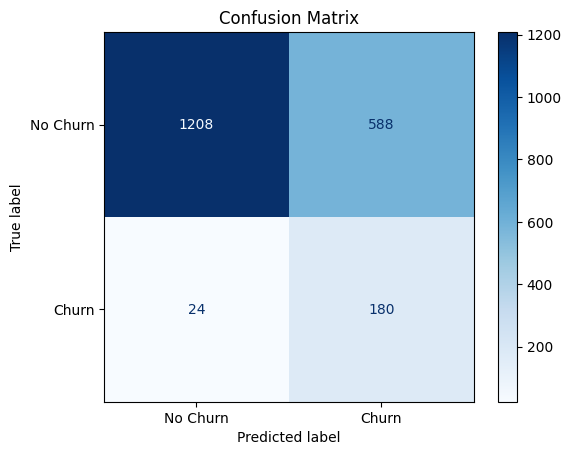

In [60]:
# Display confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn','Churn'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [61]:
# Values for true negative (tn), false positive (fp), false negative (fn), and true positive (tp)
tn, fp, fn, tp = cm.ravel()

print(f' fp: {fp} \n fn: {fn} \n tp: {tp} \n tn: {tn}')

 fp: 588 
 fn: 24 
 tp: 180 
 tn: 1208


In [62]:
# Calculations for accuracy, precision, recall
accuracy = round((tp + tn)/len(y_test), 4)
precision = round(tp/(tp + fp), 4)
recall = round(tp/(tp + fn), 4)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'-'*15)

Accuracy: 0.69
Precision: 0.23
Recall: 0.88
---------------


In [63]:
# Calculate f2 score
beta = 2
f2_score = round((1 + beta**2) * (precision * recall) / (beta**2 * precision + recall), 4)

print(f'The f2 score is {f2_score:.4f}')

The f2 score is 0.5682


In [64]:
# Profit/loss analysis
profit_loss = tp*(L - C) - fp*C - fn*L

print(f'The profit or loss is ${profit_loss:,}')

The profit or loss is $47,280


**Feature Importance**     


In [65]:
# Extract model and feature importance
model = best_model.named_steps["dtree"]
importances = model.feature_importances_

In [66]:
# Get transformed feature names
feature_names = (
    best_model.named_steps["preprocessor"]
    .get_feature_names_out()
)
feature_names = [i.split('__')[-1] for i in feature_names]  # Clean feature_names

print(f'There are {len(feature_names)} transformed feature names.')

There are 157 transformed feature names.


In [67]:
# Get selected features
feature_names = preprocessor.get_feature_names_out()

selected_features = feature_names[
    selector.get_support()
]
selected_features = [i.split('__')[-1] for i in selected_features]  # Clean feature_names

In [68]:
# Match final features with importance
importance_df = pd.DataFrame({
    "feature": selected_features,
    "importance": model.feature_importances_
}).sort_values(
    by="importance",
    ascending=False
)

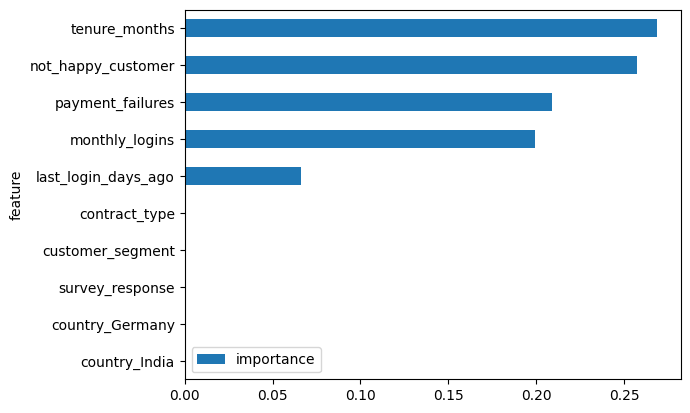

In [69]:
# Visualize
importance_df.head(10).plot(
    x="feature",
    y="importance",
    kind="barh"
)
plt.gca().invert_yaxis()
plt.show()

**SHAP Analysis**     

Unhappy customers are much more likely to churn.
Very strong and expected business signal.

Newer customers are much more likely to churn.
Long-tenure customers are more loyal.

Low monthly logins and total revenue coupled with two payment failures
are more likely to churn.


In [70]:
# Transform data
X_trans = pipe.named_steps["preprocessor"].transform(X_test)

In [71]:
# Build the transformed dataframe
feature_names = pipe.named_steps["preprocessor"].get_feature_names_out()
feature_names = [i.split('__')[-1] for i in feature_names]  # clean names
X_display = pd.DataFrame(X_trans, columns=feature_names)

In [72]:
# Initialize the TreeExplainer
explainer = shap.TreeExplainer(pipe.named_steps['dtree'])

In [73]:
# Pass the dataframe
shap_values = explainer.shap_values(X_display)

In [74]:
# Slice the 3D array: [all rows, all features, churn class index 1]
churn_shap_values = shap_values[:, :, 1]

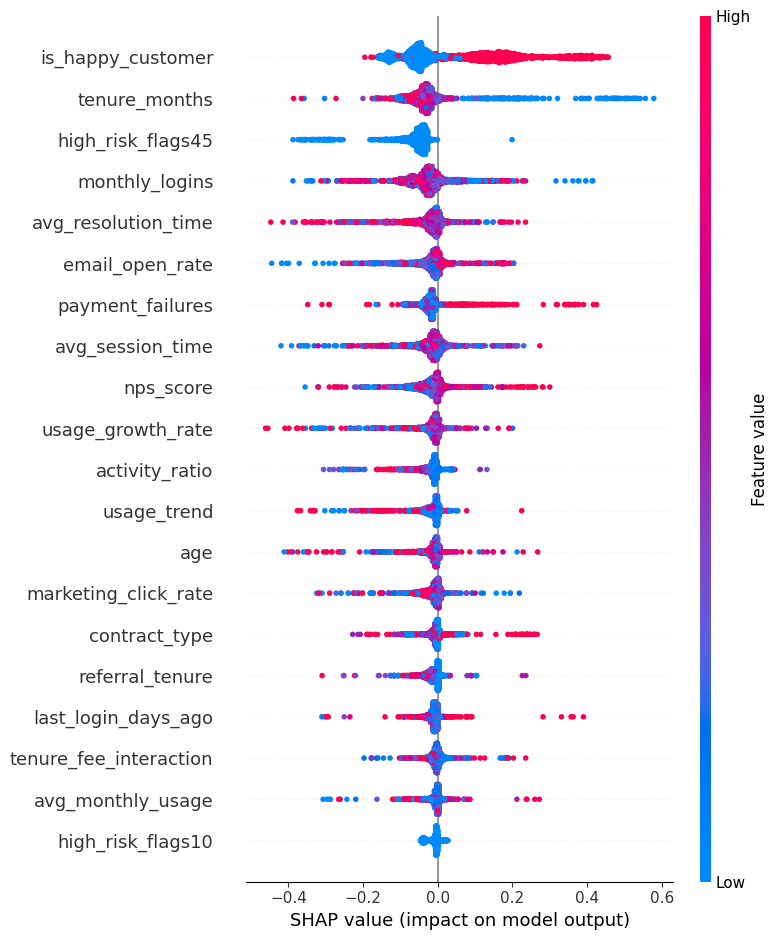

In [75]:
# Render the beeswarm plot
shap.summary_plot(churn_shap_values, X_display)

In [76]:
# Verify SHAP importance
shap_importance = pd.DataFrame({
    "feature": X_display.columns,
    "importance": np.abs(churn_shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    by="importance",
    ascending=False
)

print(shap_importance.head(30))

                    feature  importance
74        is_happy_customer    0.123938
41            tenure_months    0.061674
119       high_risk_flags45    0.060372
42           monthly_logins    0.050004
51      avg_resolution_time    0.036931
54          email_open_rate    0.034428
49         payment_failures    0.033734
44         avg_session_time    0.032806
56                nps_score    0.032079
45        usage_growth_rate    0.023922
63           activity_ratio    0.023089
64              usage_trend    0.021480
40                      age    0.020814
55     marketing_click_rate    0.020053
0             contract_type    0.016927
71          referral_tenure    0.016587
46      last_login_days_ago    0.013562
58   tenure_fee_interaction    0.012419
59        avg_monthly_usage    0.011438
85        high_risk_flags10    0.011341
4               gender_Male    0.010620
80         high_risk_flags5    0.010462
60          charge_increase    0.010155
50          support_tickets    0.008324


**Model Summary**     
A dataframe is plotted to summarize the AUC, accuracy, precision, recall, F2 score and profit/loss.     

The ultimate choice of the predictive model would need to consider the actual relative cost of missing a churner (false negatives - predicted not to churn but churned) and false alarms (false positives - predicted to churn but stayed) in order to determine the optimum mix of precision and recall.  

In [77]:
# Build dataframe
dtree_model_df = pd.DataFrame({
    'Model': ['Decision Tree'],
    'AUC': [auc],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F2_Score': [f2_score],
    'Profit_Loss': [profit_loss],
})
dtree_model_df

,Model,AUC,Accuracy,Precision,Recall,F2_Score,Profit_Loss
0,Decision Tree,0.7997,0.694,0.2344,0.8824,0.5682,47280


In [78]:
# Output model performance
dtree_model_df.to_csv("dtree_metrics.csv", index=False)

In [79]:
# Output the features importance
importance_df.to_csv("dtree_features.csv", index=False)

In [80]:
# Output the SHAP importance
shap_importance.to_csv("dtree_shap.csv", index=False)

**Sample Predictions**

In [81]:
# Obtain sample_1 from X_test
sample_1 = X_test.loc[[6563]]
proba_1 = best_model.predict_proba(sample_1)

print(f'The [[0, 1]] probabilities are {proba_1}')

The [[0, 1]] probabilities are [[0.85351946 0.14648054]]


In [82]:
# Verify actual churn

print("Actual churn:", y_test.loc[6563])

Actual churn: 1


In [83]:
# Predict a false negative
pred_1 = int(proba_1[:,1] >= best_threshold)

print("Predicted churn:", pred_1)

Predicted churn: 0


In [84]:
# Obtain sample_2 from X_test
sample_2 = X_test.loc[[4503]]
proba_2 = best_model.predict_proba(sample_2)

print(proba_2)

[[0.85351946 0.14648054]]


In [85]:
# Verify actual churn

print("Actual churn:", y_test.loc[4503])

Actual churn: 0


In [86]:
# Predict a true negative
pred_2 = int(proba_2[:,1] >= best_threshold)

print("Predicted churn:", pred_2)

Predicted churn: 0


In [87]:
# Obtain sample_3 from X_test
sample_3 = X_test.loc[[5978]]
proba_3 = best_model.predict_proba(sample_3)

print(proba_3)

[[0.85351946 0.14648054]]


In [88]:
# Verify actual churn

print("Actual churn:", y_test.loc[5978])

Actual churn: 1


In [89]:
# Predict a false negative
pred_3 = int(proba_3[:,1] >= best_threshold)

print("Predicted churn:", pred_3)

Predicted churn: 0
